# Exploratory Data Analysis & Feature Engineering

In [1]:
import pandas as pd

In [2]:
DATA_PATH = "../data/"
qualifying = pd.read_csv(DATA_PATH + 'qualifying.csv')
results = pd.read_csv(DATA_PATH + 'results.csv')
races = pd.read_csv(DATA_PATH + 'races.csv')
drivers = pd.read_csv(DATA_PATH + 'drivers.csv')
lap_times = pd.read_csv(DATA_PATH + 'lap_times.csv')

In [3]:
qualifying.shape

(11146, 9)

In [4]:
qualifying.head(-5)

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236
...,...,...,...,...,...,...,...,...,...
11136,11194,1176,860,210,87,13,1:08.061,1:07.523,\N
11137,11195,1176,807,217,27,14,1:08.066,1:07.611,\N
11138,11196,1176,839,210,31,15,1:08.231,1:07.817,\N
11139,11197,1176,861,214,43,16,1:07.894,1:08.171,\N


In [5]:
(qualifying == r'\N').sum()

qualifyId           0
raceId              0
driverId            0
constructorId       0
number              0
position            0
q1                164
q2               4818
q3               7204
dtype: int64

NaN in q1, q2, q1 mean dsq

In [6]:
results.shape

(27414, 18)

In [7]:
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.3,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [8]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 27414 entries, 0 to 27413
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         27414 non-null  int64  
 1   raceId           27414 non-null  int64  
 2   driverId         27414 non-null  int64  
 3   constructorId    27414 non-null  int64  
 4   number           27414 non-null  str    
 5   grid             27414 non-null  str    
 6   position         27414 non-null  str    
 7   positionText     27414 non-null  str    
 8   positionOrder    27414 non-null  int64  
 9   points           27414 non-null  float64
 10  laps             27414 non-null  int64  
 11  time             27414 non-null  str    
 12  milliseconds     27414 non-null  str    
 13  fastestLap       27414 non-null  str    
 14  rank             27414 non-null  str    
 15  fastestLapTime   27414 non-null  str    
 16  fastestLapSpeed  27414 non-null  str    
 17  statusId         27414 

In [9]:
results['grid'].describe()

count     27414
unique       36
top           0
freq       1638
Name: grid, dtype: object

In [10]:
results['positionOrder'].describe()

count    27414.000000
mean        12.745313
std          7.635568
min          1.000000
25%          6.000000
50%         12.000000
75%         18.000000
max         39.000000
Name: positionOrder, dtype: float64

In [11]:
results[['grid', 'positionOrder']].describe()

,positionOrder
count,27414.000000
mean,12.745313
std,7.635568
min,1.000000
25%,6.000000
50%,12.000000
75%,18.000000
max,39.000000


In [12]:
(results == r'\N').sum()

resultId               0
raceId                 0
driverId               0
constructorId          0
number                 6
grid                  20
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19320
milliseconds       19320
fastestLap         18538
rank               18280
fastestLapTime     18538
fastestLapSpeed    19162
statusId               0
dtype: int64

In [13]:
races.shape

(1171, 18)

In [14]:
races.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [15]:
(races == r'\N').sum()

raceId            0
year              0
round             0
circuitId         0
name              0
date              0
time            731
url               0
fp1_date       1035
fp1_time       1057
fp2_date       1053
fp2_time       1075
fp3_date       1065
fp3_time       1084
quali_date     1035
quali_time     1057
sprint_date    1141
sprint_time    1144
dtype: int64

In [16]:
drivers.shape

(865, 9)

In [17]:
drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [18]:
(drivers == r'\N').sum()

driverId         0
driverRef        0
number         802
code           757
forename         0
surname          0
dob              0
nationality      0
url              0
dtype: int64

* grid -> start position
* position -> finish position

In [19]:
# Kelompokkan berdasarkan posisi grid, lalu lihat rata-rata posisi finisnya (positionOrder)
grid_analysis = results.groupby('grid')['positionOrder'].agg(['mean', 'median', 'count']).reset_index()

# Tampilkan posisi start 1 sampai 10 saja untuk melihat pola awal
grid_analysis.head(10)

,grid,mean,median,count
0,0,27.139805,28.0,1638
1,1,5.583548,2.0,1167
2,10,11.677003,10.0,1161
3,11,12.051591,11.0,1163
4,12,12.113126,11.0,1158
5,13,12.756920,12.0,1156
6,14,13.267593,13.0,1151
7,15,13.507867,13.0,1144
8,16,13.685234,13.0,1131
9,17,14.243750,14.0,1120


In [20]:
# Membuat label target
results['is_podium'] = results['positionOrder'].apply(lambda x: 1 if x <= 3 else 0)

# Cek persentase distribusi
print("Persentase Driver yang Finis Podium vs Non-Podium:")
print(results['is_podium'].value_counts(normalize=True) * 100)

Persentase Driver yang Finis Podium vs Non-Podium:
is_podium
0    87.258335
1    12.741665
Name: proportion, dtype: float64


/tmp/ipykernel_100459/2411443495.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=results, x='is_podium', palette='Set2')


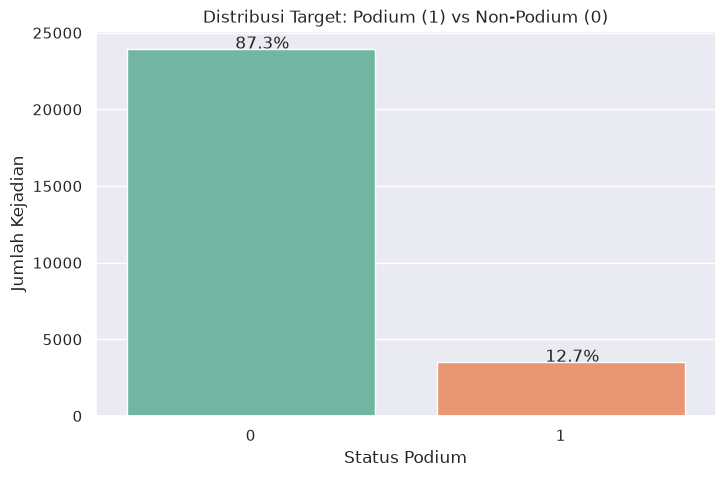

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set tema agar grafik terlihat rapi
sns.set_theme(style="darkgrid")

# Visualisasi Distribusi Podium
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=results, x='is_podium', palette='Set2')
plt.title('Distribusi Target: Podium (1) vs Non-Podium (0)')
plt.xlabel('Status Podium')
plt.ylabel('Jumlah Kejadian')

# Menambahkan angka persentase di atas batang grafik
total = len(results)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), size=12)

plt.show()

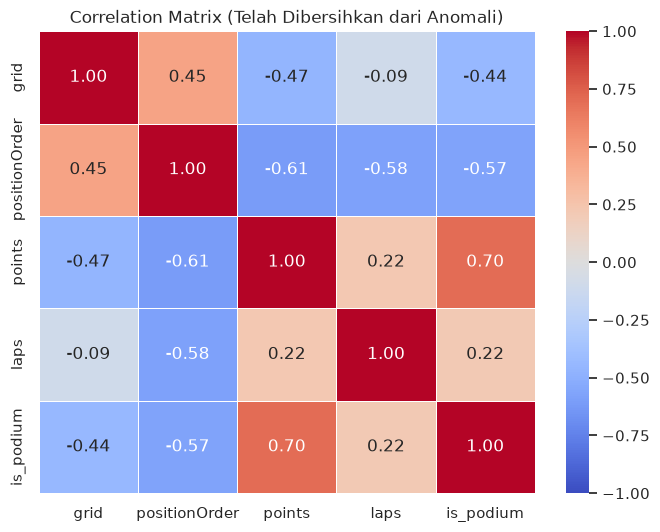

In [22]:
# 1. FIX ERROR: Paksa ubah tipe data kolom penting menjadi numerik
# Parameter errors='coerce' akan mengubah data yang tidak bisa dibaca angka menjadi NaN
kolom_penting = ['grid', 'positionOrder', 'points', 'laps', 'is_podium']

for col in kolom_penting:
    if col in results.columns:
        results[col] = pd.to_numeric(results[col], errors='coerce')

# Sekarang kode filter kamu yang sebelumnya error sudah bisa berjalan:
top_10_grid = results[results['grid'].between(1, 10)]

# 2. VISUALISASI CORRELATION MATRIX
# Ambil HANYA kolom yang sudah bertipe numerik agar heatmap tidak error
numeric_df = results.select_dtypes(include=['float64', 'int64'])

# 1. Buang kolom ID yang tidak berguna untuk analisis
kolom_id = ['resultId', 'raceId', 'driverId', 'constructorId', 'statusId']
df_bersih = numeric_df.drop(columns=kolom_id, errors='ignore')

# 2. Filter anomali: Hanya ambil data di mana posisi start (grid) lebih dari 0
df_bersih = df_bersih[df_bersih['grid'] > 0]

# 3. Hitung korelasi ulang dan plot kembali
corr_matrix_clean = df_bersih.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix_clean, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix (Telah Dibersihkan dari Anomali)')
plt.show()

In [23]:
import numpy as np

In [24]:

# 2. Bersihkan nilai '\N' yang ada di data kualifikasi jika ada
qualifying = qualifying.replace(r'\N', np.nan)

# 3. Ubah nama kolom 'position' di qualifying agar tidak bentrok dengan 'position' di results
qualifying = qualifying.rename(columns={'position': 'qualy_position'})

# 4. Pilih kolom fitur kualifikasi yang aman digunakan sebelum race dimulai
qualy_features = qualifying[['raceId', 'driverId', 'qualy_position', 'q1', 'q2', 'q3']]

# 5. Gabungkan ke dataframe utama (results) menggunakan kunci kombinasi raceId dan driverId
df_comprehensive = pd.merge(results, qualy_features, on=['raceId', 'driverId'], how='left')

# Tampilkan hasil gabungan untuk memastikan data masuk dengan benar
df_comprehensive[['raceId', 'driverId', 'grid', 'qualy_position', 'positionOrder']].head()

,raceId,driverId,grid,qualy_position,positionOrder
0,18,1,1.0,1.0,1
1,18,2,5.0,5.0,2
2,18,3,7.0,7.0,3
3,18,4,11.0,12.0,4
4,18,5,3.0,3.0,5


In [25]:
# === LAP GAP: gap to leader per lap ===
# Ambil leader time per lap (position=1)
leader_times = (
    lap_times[lap_times['position'] == 1]
    .rename(columns={'milliseconds': 'leader_ms'})
    [['raceId', 'lap', 'leader_ms']]
)

# Compute gap per lap: driver_time - leader_time
lap_gaps = (
    lap_times[['raceId', 'driverId', 'lap', 'milliseconds']]
    .merge(leader_times, on=['raceId', 'lap'], how='left')
)
lap_gaps['gap_leader_ms'] = lap_gaps['milliseconds'] - lap_gaps['leader_ms']

# Aggregate per driver per race: median + std (robust to pit stop outliers)
lap_gap_features = (
    lap_gaps
    .groupby(['raceId', 'driverId'])['gap_leader_ms']
    .agg(median_gap_leader='median', std_gap_leader='std')
    .reset_index()
)
lap_gap_features['std_gap_leader'] = lap_gap_features['std_gap_leader'].fillna(0)

# Merge ke df_comprehensive
df_comprehensive = df_comprehensive.merge(
    lap_gap_features, on=['raceId', 'driverId'], how='left'
)


In [26]:
def time_to_seconds(time_str):
    # Jika datanya kosong (NaN) atau bukan string, kembalikan sebagai NaN
    if pd.isna(time_str) or not isinstance(time_str, str):
        return np.nan
    
    try:
        # Pisahkan menit dan detik berdasarkan karakter ':'
        parts = time_str.split(':')
        if len(parts) == 2:
            minutes = int(parts[0])
            seconds = float(parts[1])
            return (minutes * 60) + seconds
        else:
            # Jika formatnya kebetulan langsung detik (misal: "81.432")
            return float(time_str)
    except:
        # Jika ada format aneh yang tidak terprediksi, amankan menjadi NaN
        return np.nan

# 2. Terapkan fungsi ke kolom q1, q2, dan q3, lalu simpan ke kolom baru
kolom_kualifikasi = ['q1', 'q2', 'q3']
for col in kolom_kualifikasi:
    # Membuat kolom baru dengan akhiran '_sec' agar data aslinya tetap ada
    df_comprehensive[f'{col}_sec'] = df_comprehensive[col].apply(time_to_seconds)

# 3. Intip hasilnya untuk memastikan konversi berhasil
print("Hasil Konversi Waktu Kualifikasi (Teks vs Detik):")
display(df_comprehensive[['q1', 'q1_sec', 'q2', 'q2_sec', 'q3', 'q3_sec']].head(10))

Hasil Konversi Waktu Kualifikasi (Teks vs Detik):


,q1,q1_sec,q2,q2_sec,q3,q3_sec
0,1:26.572,86.572,1:25.187,85.187,1:26.714,86.714
1,1:25.960,85.960,1:25.518,85.518,1:27.236,87.236
2,1:26.295,86.295,1:26.059,86.059,1:28.687,88.687
3,1:26.907,86.907,1:26.188,86.188,NaN,NaN
4,1:25.664,85.664,1:25.452,85.452,1:27.079,87.079
5,1:26.891,86.891,1:26.413,86.413,NaN,NaN
6,1:27.446,87.446,NaN,NaN,NaN,NaN
7,1:26.140,86.140,NaN,NaN,NaN,NaN
8,1:26.103,86.103,1:25.315,85.315,1:26.869,86.869
9,1:26.919,86.919,1:26.164,86.164,1:29.593,89.593


In [27]:
# Ambil nilai minimum (tercepat) dari kolom q1_sec, q2_sec, q3_sec
# axis=1 berarti mencari nilai minimum secara horizontal (per baris pembalap)
df_comprehensive['best_qualy_sec'] = df_comprehensive[['q1_sec', 'q2_sec', 'q3_sec']].min(axis=1)

# Lihat hasilnya
display(df_comprehensive[['driverId', 'grid', 'q1_sec', 'q2_sec', 'q3_sec', 'best_qualy_sec']].head())

,driverId,grid,q1_sec,q2_sec,q3_sec,best_qualy_sec
0,1,1.0,86.572,85.187,86.714,85.187
1,2,5.0,85.960,85.518,87.236,85.518
2,3,7.0,86.295,86.059,88.687,86.059
3,4,11.0,86.907,86.188,NaN,86.188
4,5,3.0,85.664,85.452,87.079,85.452


In [28]:
df_comprehensive.info()

<class 'pandas.DataFrame'>
RangeIndex: 27414 entries, 0 to 27413
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   resultId           27414 non-null  int64  
 1   raceId             27414 non-null  int64  
 2   driverId           27414 non-null  int64  
 3   constructorId      27414 non-null  int64  
 4   number             27414 non-null  str    
 5   grid               27394 non-null  float64
 6   position           27414 non-null  str    
 7   positionText       27414 non-null  str    
 8   positionOrder      27414 non-null  int64  
 9   points             27414 non-null  float64
 10  laps               27414 non-null  int64  
 11  time               27414 non-null  str    
 12  milliseconds       27414 non-null  str    
 13  fastestLap         27414 non-null  str    
 14  rank               27414 non-null  str    
 15  fastestLapTime     27414 non-null  str    
 16  fastestLapSpeed    27414 non-null

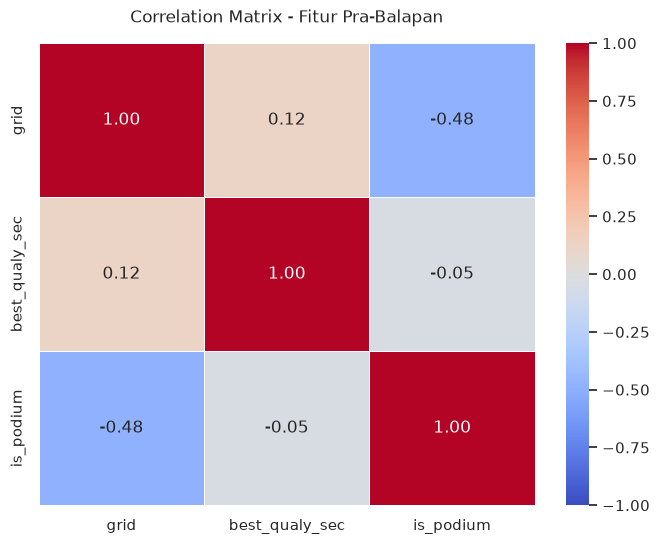

In [29]:

# 1. Pilih kolom yang relevan dan AMAN digunakan sebelum balapan (Pra-Balapan)
# Kita buang 'points', 'laps', dan 'positionOrder' karena itu adalah hasil akhir balapan (Data Leakage)
kolom_pra_balapan = ['grid', 'best_qualy_sec', 'is_podium']

# 2. Buat dataframe khusus untuk korelasi dengan membuang baris yang memiliki missing values di kolom tersebut
df_corr = df_comprehensive[kolom_pra_balapan].dropna()

# 3. Hitung matriks korelasi
corr_matrix_new = df_corr.corr()

# 4. Visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix_new, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix - Fitur Pra-Balapan', pad=15)
plt.show()

waktu absolut dalam detik tidak bisa dibandingkan lintas sirkuit.

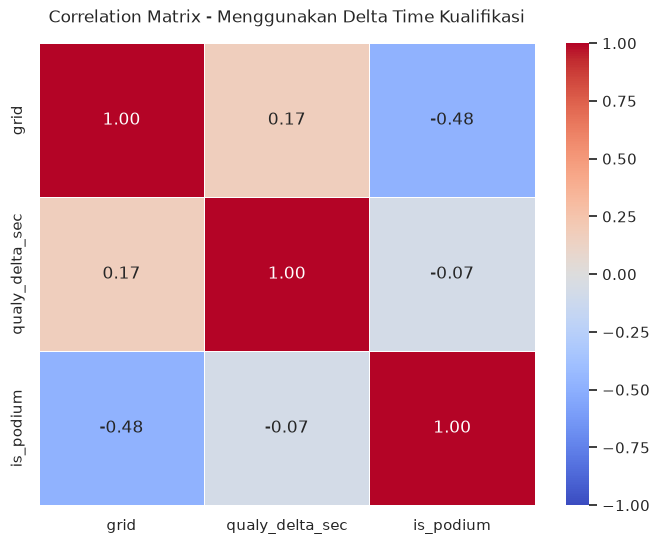

In [30]:
# 1. Cari waktu kualifikasi tercepat untuk setiap balapan (raceId)
fastest_qualy_per_race = df_comprehensive.groupby('raceId')['best_qualy_sec'].transform('min')

# 2. Hitung selisih waktu (Delta) setiap pembalap dengan waktu tercepat di sesi balapan tersebut
# Hasilnya: Pole position = 0.0 detik. Posisi ke-2 mungkin 0.2 detik, dst.
df_comprehensive['qualy_delta_sec'] = df_comprehensive['best_qualy_sec'] - fastest_qualy_per_race

# 3. Ambil kolom baru dan buang missing values
kolom_pra_balapan_baru = ['grid', 'qualy_delta_sec', 'is_podium']
df_corr_baru = df_comprehensive[kolom_pra_balapan_baru].dropna()

# 4. Hitung korelasi dan plot ulang
corr_matrix_delta = df_corr_baru.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix_delta, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix - Menggunakan Delta Time Kualifikasi', pad=15)
plt.show()

data quay_delta_sec vs is_podium (non-linear)

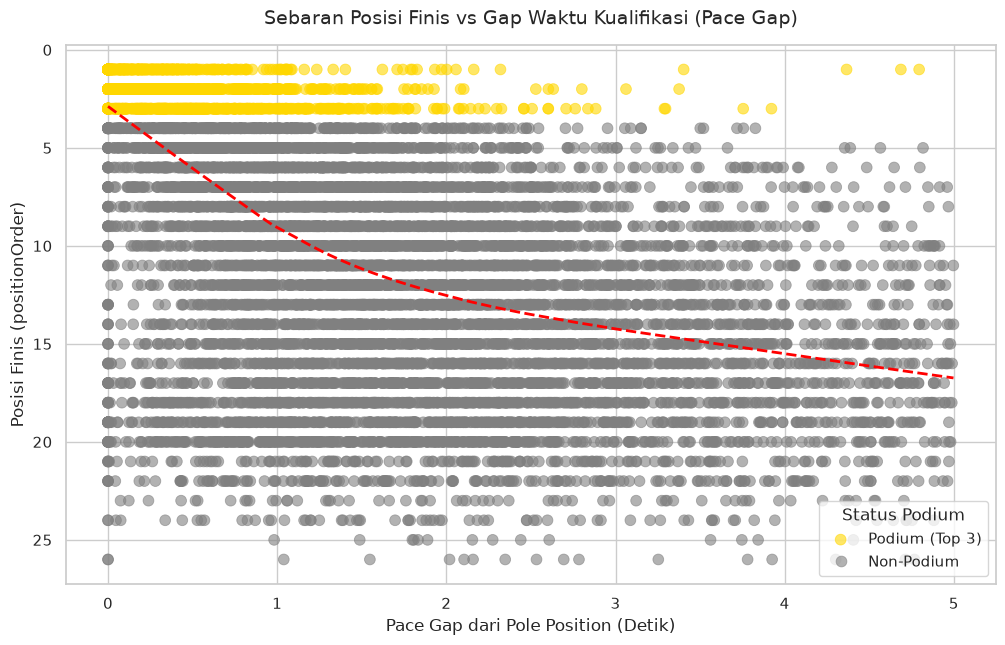

In [31]:
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Filter anomali ekstrem (misal delta time di atas 5 detik biasanya karena crash/hujan/masalah mesin di kualifikasi)
df_plot = df_comprehensive[df_comprehensive['qualy_delta_sec'] < 5].copy()

# Buat scatter plot utama
sns.scatterplot(
    data=df_plot,
    x='qualy_delta_sec',
    y='positionOrder',
    hue='is_podium',
    palette={1: 'gold', 0: 'gray'},
    alpha=0.6,
    s=60, # ukuran titik
    edgecolor=None
)

# Tambahkan garis tren non-linier (LOWESS) untuk membuktikan kurvanya
sns.regplot(
    data=df_plot,
    x='qualy_delta_sec',
    y='positionOrder',
    scatter=False,
    color='red',
    lowess=True,
    line_kws={'linewidth': 2, 'linestyle': '--'}
)

# Balik sumbu Y agar Posisi 1 berada di atas (puncak podium)
plt.gca().invert_yaxis()

plt.title('Sebaran Posisi Finis vs Gap Waktu Kualifikasi (Pace Gap)', fontsize=14, pad=15)
plt.xlabel('Pace Gap dari Pole Position (Detik)', fontsize=12)
plt.ylabel('Posisi Finis (positionOrder)', fontsize=12)

# Rapikan legenda
plt.legend(title='Status Podium', labels=['Podium (Top 3)', 'Non-Podium'], loc='lower right')
plt.show()

1. Bentuk Kurva Non-Linier: Garis merahnya jelas melengkung, tidak lurus. Ini adalah bukti visual tak terbantahkan mengapa metrik korelasi Pearson (yang mengasumsikan garis lurus) gagal mendeteksi hubungan kuat dan hanya memberikan angka -0.07 sebelumnya.

2. "Zona Elit" (0.0 - 1.0 Detik): Perhatikan area kiri. Hampir semua titik emas (podium) berkerumun di selisih waktu 0 hingga 1 detik dari Pole Position. Di zona ini, kurva merah menukik tajam, artinya kecepatan murni mobil sangat berkorelasi dengan hasil akhir.

3. Kekacauan Papan Tengah (> 1.5 Detik): Lewat dari 1.5 detik, sebaran titik abu-abu menjadi sangat acak (bisa finis ke-5, bisa finis ke-20) dan garis merahnya mulai melandai. Di area ini, dominasi kecepatan mobil menghilang; hasil balapan lebih ditentukan oleh ketahanan ban, strategi pit stop, atau keberuntungan menghindari kecelakaan.

In [32]:
# Load tabel pendukung
standings = pd.read_csv(DATA_PATH + 'driver_standings.csv')
races_info = pd.read_csv(DATA_PATH + 'races.csv')[['raceId', 'year', 'round']]

# 1. Gabungkan standings dengan info balapan (year dan round)
standings_merged = pd.merge(standings, races_info, on='raceId', how='left')

# 2. FEATURE ENGINEERING: Teknik Lagging (+1)
# Klasemen setelah Ronde ke-N akan menjadi prediktor untuk balapan Ronde ke-(N+1)
standings_merged['round_target'] = standings_merged['round'] + 1

# 3. Pilih kolom klasemen yang penting untuk model
prior_standings = standings_merged[['year', 'round_target', 'driverId', 'points', 'position', 'wins']]

# Ganti nama kolom agar jelas bahwa ini adalah data SEBELUM balapan dimulai
prior_standings = prior_standings.rename(columns={
    'points': 'prior_points',
    'position': 'prior_position',
    'wins': 'prior_wins'
})

# 4. Pastikan dataframe utama memiliki kolom year dan round (jika belum ada)
if 'year' not in df_comprehensive.columns or 'round' not in df_comprehensive.columns:
    df_comprehensive = pd.merge(df_comprehensive, races_info, on='raceId', how='left')

# 5. Gabungkan dataframe utama dengan klasemen masa lalu (prior_standings)
df_final = pd.merge(
    df_comprehensive, 
    prior_standings, 
    left_on=['year', 'round', 'driverId'], 
    right_on=['year', 'round_target', 'driverId'], 
    how='left'
)

# 6. PENANGANAN KASUS KHUSUS: Balapan Ronde 1
# Pada balapan pertama setiap musim, tidak ada klasemen sebelumnya (hasil merge akan NaN)
# Kita isi nilai NaN tersebut dengan baseline awal musim: 0 poin dan 0 kemenangan
df_final['prior_points'] = df_final['prior_points'].fillna(0)
df_final['prior_wins'] = df_final['prior_wins'].fillna(0)

# Untuk posisi klasemen (prior_position) di Ronde 1, kita bisa isi dengan posisi paling bawah (misal 20)
df_final['prior_position'] = df_final['prior_position'].fillna(20)

# Buang kolom round_target karena sudah tidak terpakai
df_final = df_final.drop(columns=['round_target'], errors='ignore')

# Intip hasilnya untuk memvalidasi
print("Data Standings yang Sudah Bebas dari Data Leakage:")
display(df_final[['year', 'round', 'driverId', 'grid', 'prior_points', 'prior_position', 'is_podium']].head(-5))

Data Standings yang Sudah Bebas dari Data Leakage:


,year,round,driverId,grid,prior_points,prior_position,is_podium
0,2008,1,1,1.0,0.0,20,1
1,2008,1,2,5.0,0.0,20,1
2,2008,1,3,7.0,0.0,20,1
3,2008,1,4,11.0,0.0,20,0
4,2008,1,5,3.0,0.0,20,0
...,...,...,...,...,...,...,...
27404,2026,8,842,11.0,41.0,8,0
27405,2026,8,860,13.0,18.0,12,0
27406,2026,8,861,16.0,19.0,11,0
27407,2026,8,839,15.0,3.0,16,0


In [33]:
# 1. Tentukan fitur prediktor (X) yang AMAN dan target (y)
# Kita tinggalkan semua kolom seperti 'points', 'laps', 'positionOrder', 'statusId', dll.
kolom_fitur = [
    'grid', 
    'qualy_delta_sec', 
    'prior_points', 
    'prior_position', 
    'prior_wins'
]

# Pastikan tidak ada data kosong yang tersisa di fitur-fitur penting ini
df_model = df_final.dropna(subset=kolom_fitur).copy()

# 2. Pemisahan Data Berdasarkan Waktu (Temporal Split)
# Misalnya: Kita jadikan musim 2023 ke atas sebagai data Uji (Testing), sisanya Pelatihan (Training)
tahun_batas_test = 2023

data_train = df_model[df_model['year'] < tahun_batas_test]
data_test = df_model[df_model['year'] >= tahun_batas_test]

# 3. Pisahkan X (Fitur) dan y (Target)
X_train = data_train[kolom_fitur]
y_train = data_train['is_podium']

X_test = data_test[kolom_fitur]
y_test = data_test['is_podium']

print(f"Jumlah Data Train (Sebelum {tahun_batas_test}): {len(X_train)} baris")
print(f"Jumlah Data Test ({tahun_batas_test} - Sekarang): {len(X_test)} baris")

# 4. Cek struktur final dataset
X_train.head()

Jumlah Data Train (Sebelum 2023): 9428 baris
Jumlah Data Test (2023 - Sekarang): 1536 baris


,grid,qualy_delta_sec,prior_points,prior_position,prior_wins
0,1.0,0.000,0.0,20,0.0
1,5.0,0.331,0.0,20,0.0
2,7.0,0.872,0.0,20,0.0
3,11.0,1.001,0.0,20,0.0
4,3.0,0.265,0.0,20,0.0


In [34]:
# Simpan dataset yang sudah matang ke dalam folder dataset
# Kita gunakan index=False agar nomor baris bawaan pandas tidak ikut tersimpan menjadi kolom baru
df_final.to_csv(DATA_PATH + 'processed_features.csv', index=False)

print("Dataset siap digunakan! Berhasil disimpan sebagai processed_features.csv")

Dataset siap digunakan! Berhasil disimpan sebagai processed_features.csv
